In [1]:
import pandas as pd

In [2]:
features = pd.read_csv(
    './data/fma_metadata/fma_metadata/features.csv',
    header=[0, 1],
    index_col=0
)


print(features.shape)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16032\3791766483.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(


(106576, 518)


# Nan vrednosti

In [3]:
features = features.dropna()

# Outlayeri i ektremne vrednosti

In [4]:
from scipy import stats
import numpy as np

In [5]:
z_scores = np.abs(stats.zscore(features))
features = features[(z_scores < 3).all(axis=1)]

# Standardizujemo podatke

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

In [8]:
X = scaler.fit_transform(features)

In [9]:
X = pd.DataFrame(X,columns=features.columns)
X

feature    chroma_cens                                                         \
statistics    kurtosis kurtosis.1 kurtosis.2 kurtosis.3 kurtosis.4 kurtosis.5   
0             2.121688   1.047214   0.388807   2.808331   2.007656   0.110324   
1            -0.171536  -0.106919   0.232631   0.393980   0.992502   0.129802   
2            -0.752495  -0.889164   0.981574   0.192528  -0.417579  -1.405576   
3            -1.118660   1.253957   0.587371  -1.139874  -1.058868  -1.233616   
4             1.119134   0.882389   1.240533  -1.150107  -1.205114  -0.003172   
...                ...        ...        ...        ...        ...        ...   
41679        -1.089284  -0.144368   0.691709  -0.376616  -0.831396   0.299159   
41680        -0.092372  -0.287423  -0.590188  -0.632810  -0.853638  -0.384738   
41681        -0.466307  -0.144313  -0.525895  -0.412829   0.247918  -0.264944   
41682         0.650173  -0.000986  -0.564335   0.399403  -0.161716  -0.567439   
41683        -0.152889   0.357272  -0.041379   0.524720   0.173289  -0.937006   

feature                                                 ...   tonnetz  \
statistics kurtosis.6 kurtosis.7 kurtosis.8 kurtosis.9  ...     std.3   
0            1.666842   1.190928   0.264925   0.761159  ... -1.159958   
1           -0.248902  -0.858638   0.188924  -0.812587  ... -0.168989   
2           -1.348853  -1.436476  -0.934149   3.029402  ...  1.315314   
3            1.435657  -1.062654  -1.158182  -0.725348  ...  1.323642   
4           -0.930391  -0.968018  -0.742119   0.750162  ...  0.125904   
...               ...        ...        ...        ...  ...       ...   
41679       -0.626742  -0.821418  -0.879126   1.762404  ... -0.533392   
41680       -0.578199   0.643918  -0.933927  -1.033443  ... -0.344167   
41681       -0.640820  -0.054675  -0.134394  -0.467756  ...  1.037838   
41682        2.067862   1.590157   1.704583   0.209827  ...  0.254515   
41683       -0.817523   0.722160  -0.609261  -0.793211  ... -0.381732   

feature                              zcr                                \
statistics     std.4     std.5  kurtosis       max      mean    median   
0          -1.419694 -0.757903 -0.622572  0.479108  1.718578  1.196977   
1           0.258204 -0.025421 -0.170428  0.499765 -0.142847 -0.071499   
2          -0.160489  0.797630 -0.448110  0.966028  0.215529 -0.278597   
3           0.696107  0.754089  0.086984 -0.093392 -0.850946 -1.003441   
4          -0.909187 -0.205993 -0.716080 -0.919680  0.037164  0.498021   
...              ...       ...       ...       ...       ...       ...   
41679       0.044618  0.136881 -0.337424 -0.562606 -0.128493  0.057937   
41680      -0.406068 -0.579879 -0.423611 -0.966897 -0.358663 -0.097387   
41681       0.472010  1.022374 -0.608009 -1.152812 -0.945597 -0.718681   
41682      -0.745278 -0.204516 -0.637855 -1.052477 -0.580133 -0.226823   
41683      -0.585544 -0.718203 -0.512710 -1.326923 -0.429132 -0.175048   

feature                                   
statistics       min      skew       std  
0          -0.738305 -0.627969  1.561175  
1          -0.378795  0.053664 -0.380722  
2           0.160470 -0.383661  0.717468  
3          -0.738305  0.616747  0.025685  
4           0.519981 -1.284498 -0.689373  
...              ...       ...       ...  
41679      -0.019285 -0.258848 -0.631030  
41680       1.598512 -0.501945 -0.973593  
41681       0.160470 -0.828634 -0.985207  
41682       0.519981 -1.038935 -1.043698  
41683       1.059246 -0.580765 -0.930788  

[41684 rows x 518 columns]

In [10]:
X.describe()

feature      chroma_cens                                            \
statistics      kurtosis    kurtosis.1    kurtosis.2    kurtosis.3   
count       4.168400e+04  4.168400e+04  4.168400e+04  4.168400e+04   
mean       -8.182049e-18  5.454699e-18 -8.182049e-18 -1.636410e-17   
std         1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min        -1.883780e+00 -1.932772e+00 -1.842840e+00 -1.984606e+00   
25%        -6.498575e-01 -6.654844e-01 -6.597788e-01 -6.649377e-01   
50%        -2.026800e-01 -1.912871e-01 -2.004782e-01 -1.916734e-01   
75%         3.989368e-01  4.206259e-01  4.082223e-01  4.283430e-01   
max         1.336608e+01  1.079670e+01  8.991587e+00  1.284209e+01   

feature                                                             \
statistics    kurtosis.4    kurtosis.5    kurtosis.6    kurtosis.7   
count       4.168400e+04  4.168400e+04  4.168400e+04  4.168400e+04   
mean        2.727350e-18 -1.636410e-17  1.636410e-17 -2.727350e-18   
std         1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min        -1.927357e+00 -1.902654e+00 -1.828032e+00 -1.858171e+00   
25%        -6.651149e-01 -6.654377e-01 -6.657964e-01 -6.581292e-01   
50%        -1.993451e-01 -1.952863e-01 -2.029177e-01 -2.049270e-01   
75%         4.181062e-01  4.233062e-01  4.209453e-01  4.125682e-01   
max         1.068872e+01  1.067255e+01  1.053391e+01  1.143435e+01   

feature                                 ...       tonnetz                \
statistics    kurtosis.8    kurtosis.9  ...         std.3         std.4   
count       4.168400e+04  4.168400e+04  ...  4.168400e+04  4.168400e+04   
mean        1.363675e-17  3.272819e-17  ...  3.545554e-16 -8.182049e-17   
std         1.000012e+00  1.000012e+00  ...  1.000012e+00  1.000012e+00   
min        -1.979657e+00 -1.832805e+00  ... -2.358358e+00 -2.803304e+00   
25%        -6.605836e-01 -6.595057e-01  ... -7.539918e-01 -7.381453e-01   
50%        -1.922131e-01 -2.025715e-01  ... -1.236058e-01 -1.428136e-01   
75%         4.159151e-01  4.132545e-01  ...  6.372907e-01  6.026280e-01   
max         1.108585e+01  1.077829e+01  ...  3.661248e+00  7.087665e+00   

feature                            zcr                              \
statistics         std.5      kurtosis           max          mean   
count       4.168400e+04  4.168400e+04  4.168400e+04  4.168400e+04   
mean        4.254665e-16 -1.090940e-17 -1.254581e-16  1.472769e-16   
std         1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min        -2.532428e+00 -7.721897e-01 -2.061729e+00 -2.299530e+00   
25%        -7.359103e-01 -5.737185e-01 -7.160592e-01 -7.236421e-01   
50%        -1.377112e-01 -3.639272e-01 -1.317551e-01 -1.267729e-01   
75%         6.041535e-01  1.263065e-01  4.525489e-01  5.702715e-01   
max         6.813133e+00  8.815575e+00  3.288489e+00  5.023823e+00   

feature                                                             
statistics        median           min          skew           std  
count       4.168400e+04  4.168400e+04  4.168400e+04  4.168400e+04  
mean        1.090940e-17 -7.772946e-17  7.091109e-17  1.622773e-16  
std         1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  
min        -2.194256e+00 -7.383054e-01 -2.127024e+00 -1.790023e+00  
25%        -7.445683e-01 -7.383054e-01 -6.885467e-01 -7.345785e-01  
50%        -1.491611e-01 -3.787951e-01 -2.559944e-01 -2.340928e-01  
75%         5.756825e-01  5.199808e-01  4.140087e-01  5.199566e-01  
max         5.105955e+00  6.631656e+00  4.291874e+00  4.253270e+00  

[8 rows x 518 columns]

# Smanjujemo dimenzionalnost podataka

In [11]:
from sklearn.decomposition import PCA

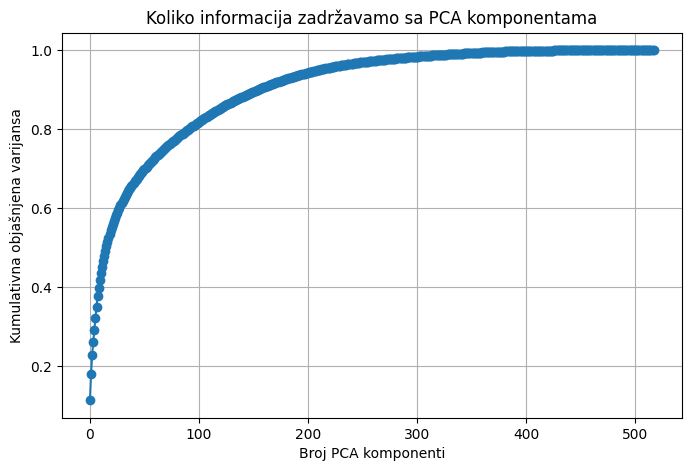

In [12]:
import matplotlib.pyplot as plt


pca = PCA(n_components=X.shape[1])
pca.fit(X)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(cumulative_var, marker='o')
plt.xlabel('Broj PCA komponenti')
plt.ylabel('Kumulativna objašnjena varijansa')
plt.title('Koliko informacija zadržavamo sa PCA komponentama')
plt.grid(True)
plt.show()

# Koristicemo pca za 60 i 100 komponenata

In [13]:
pca60 = PCA(n_components=60)
X_pca60 = pca60.fit_transform(X)

pca100 = PCA(n_components=100)
X_pca100 = pca100.fit_transform(X)

In [14]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AffinityPropagation, Birch, SpectralClustering
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

In [15]:
algorithms = {
    "GMM": GaussianMixture(n_components=10, random_state=42),
    "AffinityPropagation": AffinityPropagation(random_state=42),
    "BIRCH": Birch(n_clusters=10),
    "SpectralClustering": SpectralClustering(n_clusters=10, assign_labels='discretize', random_state=42),
    "HDBSCAN": HDBSCAN(min_cluster_size=15)
}

In [16]:
sample_size = 10000
indices = np.random.choice(X_pca100.shape[0], size=sample_size, replace=False)
X_sample = X_pca100[indices]

In [52]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from dbcv import dbcv

In [54]:
def run_clustering(X, algorithm, use_sample=False, sample_size=10000):
    if use_sample:
        idx = np.random.choice(len(X), sample_size, replace=False)
        X_use = X[idx]
    else:
        X_use = X

    labels = (
        algorithm.fit_predict(X_use)
        if hasattr(algorithm, "fit_predict")
        else algorithm.fit(X_use).labels_
    )

    results = {}

    mask = labels != -1
    if len(set(labels[mask])) > 1:
        results["silhouette"] = silhouette_score(X_use[mask], labels[mask])
        results["calinski_harabasz"] = calinski_harabasz_score(X_use[mask], labels[mask])
    else:
        results["silhouette"] = np.nan
        results["calinski_harabasz"] = np.nan

    try:
        results["dbcv"] = dbcv(X_use, labels)
    except:
        results["dbcv"] = np.nan

    return results



In [41]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=10, random_state=42)

res_gmm_pca60 = run_clustering(X_pca60, gmm, use_sample=True)
print("GMM pca60:", res_gmm_pca60)
res_gmm_pca100 = run_clustering(X_pca100, gmm, use_sample=True)
print("GMM pca100:", res_gmm_pca100)

GMM pca60: {'silhouette': 0.0030349735611126397, 'calinski_harabasz': 261.25618498337866, 'dbcv': nan}
GMM pca100: {'silhouette': 0.016833195846563027, 'calinski_harabasz': 238.44831811974495, 'dbcv': nan}


In [39]:
from sklearn.cluster import OPTICS

optics = OPTICS(
    min_samples=10,
    xi=0.05,
    min_cluster_size=50
)

res_optics_pca60 = run_clustering(X_pca60, optics, use_sample=True)
print("OPTICS pca60:", res_optics_pca60)
res_optics_pca100 = run_clustering(X_pca100, optics, use_sample=True)
print("OPTICS pca100:", res_optics_pca100)

OPTICS pca60: {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': nan}
OPTICS pca100: {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': nan}


In [26]:
from sklearn.cluster import Birch

birch = Birch(n_clusters=None)

res_birch_pca60 = run_clustering(X_pca60, birch)
print("BIRCH pca60:", res_birch_pca60)
res_birch_pca100 = run_clustering(X_pca100, birch)
print("BIRCH pca100:", res_birch_pca100)


BIRCH: {'silhouette': 0.028658485301376012, 'calinski_harabasz': 31620.161188617127}


In [27]:
from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(damping=0.9, random_state=42)

res_ap = run_clustering(X_pca60, ap, use_sample=True, sample_size=3000)
print("Affinity:", res_ap)


Affinity: {'silhouette': 0.01095124748512805, 'calinski_harabasz': 14.915073026531488}


In [55]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(
    min_cluster_size=15,
    min_samples=10,
    copy=True
)

res_hdb_pca60 = run_clustering(X_pca60, hdb, use_sample=True)
print('DBSCAN pca60', res_hdb_pca60)
res_hdb_pca100 = run_clustering(X_pca100, hdb, use_sample=True)
print('DBSCAN pca100', res_hdb_pca100)

DBSCAN pca60 {'silhouette': 0.37388981781298153, 'calinski_harabasz': 35.1577724929675, 'dbcv': 0.0007456597198711556}
DBSCAN pca100 {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': 0.0}


In [58]:
algorithms = {
    "GMM": GaussianMixture(n_components=10, random_state=42),
    "HDBSCAN": HDBSCAN(min_cluster_size=15, min_samples=10),
    "OPTICS": OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05),
    "AffinityPropagation": AffinityPropagation(damping=0.9, max_iter=200),
    "Birch": Birch(threshold=0.5, branching_factor=50,  n_clusters=None)
}


for name, alg in algorithms.items():
    print(f"\n=== {name} ===")
    res_pca60 = run_clustering(X_pca60, alg, use_sample=True)
    res_pca100 = run_clustering(X_pca100, alg, use_sample=True)

    print("PCA60:", res_pca60)
    print("PCA100:", res_pca100)


=== GMM ===
PCA60: {'silhouette': -0.008541267032948826, 'calinski_harabasz': 242.6543367465127, 'dbcv': nan}
PCA100: {'silhouette': 0.009275992727395177, 'calinski_harabasz': 211.50538655325806, 'dbcv': nan}

=== HDBSCAN ===


D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


PCA60: {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': 0.0}
PCA100: {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': 0.0}

=== OPTICS ===
PCA60: {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': nan}
PCA100: {'silhouette': nan, 'calinski_harabasz': nan, 'dbcv': nan}

=== AffinityPropagation ===


D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
D:\Ip2\.venv\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


PCA60: {'silhouette': 0.006408584282445216, 'calinski_harabasz': 20.852809018986996, 'dbcv': nan}
PCA100: {'silhouette': 0.0016204867408604177, 'calinski_harabasz': 19.069724716435623, 'dbcv': nan}

=== Birch ===
PCA60: {'silhouette': 0.00758685154592991, 'calinski_harabasz': 34155.55319392253, 'dbcv': nan}
PCA100: {'silhouette': 0.009381093631537146, 'calinski_harabasz': 41222.97360890718, 'dbcv': nan}
